# Logistic Regression and Classification

While Linear Regression is perfect for predicting continuous numbers (like house prices), it fails completely when we need to predict **categories**. 

**Classification** is a supervised learning task where the target variable $y$ can only take on discrete values. In **Binary Classification**, there are only two possible outcomes:
*   **$0$ (Negative Class):** e.g., Not a spam email, Tumor is benign, Transaction is not fraudulent.
*   **$1$ (Positive Class):** e.g., Is a spam email, Tumor is malignant, Transaction is fraudulent.

---

### **1. Why Linear Regression Fails for Classification**

If we try to fit a straight line $f_{\vec{w},b}(\vec{x}) = \vec{w} \cdot \vec{x} + b$ to data that is strictly $0$ or $1$, two major problems occur:
1.  The predictions will frequently be less than $0$ or greater than $1$, which makes no mathematical sense for probabilities.
2.  An extreme **outlier** (like a massive benign tumor) will drastically pull the regression line. This shifts the $0.5$ threshold and causes the model to misclassify obvious data points.

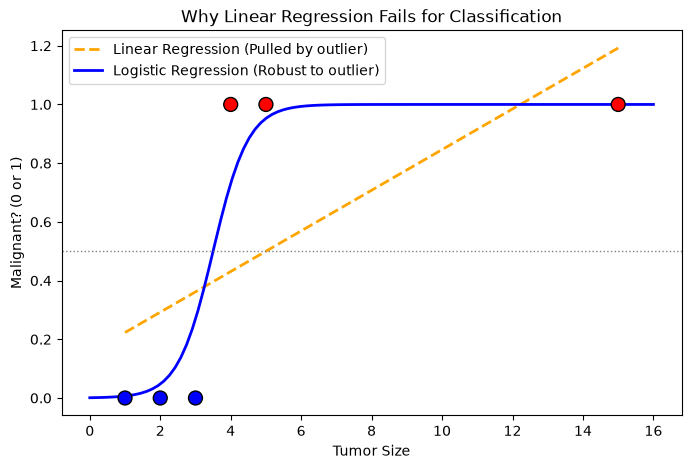

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Visualizing the Outlier Problem
# Imagine predicting if a tumor is malignant (1) or benign (0) based on size
X_tumor = np.array([1, 2, 3, 4, 5, 15])  # Notice the outlier at size 15
y_tumor = np.array([0, 0, 0, 1, 1, 1])

# Fit a simple linear line (y = mx + c) using numpy for demonstration
m, c = np.polyfit(X_tumor, y_tumor, 1)
lin_pred = m * X_tumor + c

# Create a conceptual S-curve (Logistic fit)
x_range = np.linspace(0, 16, 100)
log_pred = 1 / (1 + np.exp(-(x_range - 3.5) * 2))

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(X_tumor, y_tumor, c=y_tumor, cmap='bwr', s=100, edgecolors='k', zorder=3)
ax.plot(X_tumor, lin_pred, c='orange', lw=2, ls='--', label="Linear Regression (Pulled by outlier)")
ax.plot(x_range, log_pred, c='blue', lw=2, label="Logistic Regression (Robust to outlier)")

ax.axhline(0.5, color='gray', lw=1, ls=':')
ax.set_title("Why Linear Regression Fails for Classification")
ax.set_xlabel("Tumor Size")
ax.set_ylabel("Malignant? (0 or 1)")
ax.legend()
plt.show()

### **2. The Sigmoid (Logistic) Function**

To fix this, we must force our model to only output values between $0$ and $1$. We achieve this by wrapping our standard linear equation inside a mathematical function called the **Sigmoid Function** (or Logistic Function).

**The Formula:**
$$g(z) = \frac{1}{1 + e^{-z}}$$

*   When $z$ is a large positive number, $e^{-z}$ becomes very small, and $g(z)$ approaches $1$.
*   When $z$ is a large negative number, $e^{-z}$ becomes massive, and $g(z)$ approaches $0$.
*   When $z = 0$, $g(z) = 0.5$.

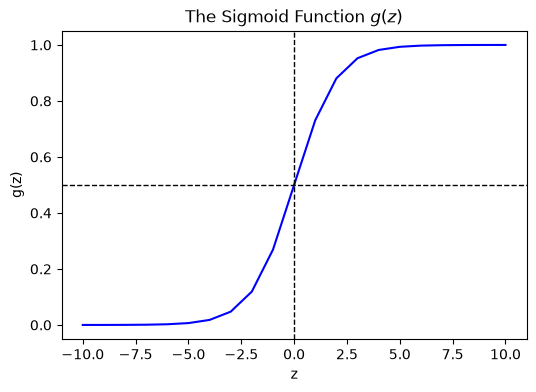

In [8]:
def sigmoid(z):
    """
    Compute the sigmoid of z
    """
    return 1 / (1 + np.exp(-z))

# Visualize the mathematical Sigmoid Curve
z_tmp = np.arange(-10, 11)
y_tmp = sigmoid(z_tmp)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(z_tmp, y_tmp, c="b")
ax.set_title("The Sigmoid Function $g(z)$")
ax.set_ylabel("g(z)")
ax.set_xlabel("z")
ax.axvline(0, color='black', lw=1, ls='--')
ax.axhline(0.5, color='black', lw=1, ls='--')
plt.show()

### **3. The Logistic Regression Model**

To build the Logistic Regression model, we simply take our multiple linear regression equation $z = \vec{w} \cdot \vec{x} + b$ and pass it directly into the sigmoid function.

$$f_{\vec{w},b}(\vec{x}) = g(\vec{w} \cdot \vec{x} + b) = \frac{1}{1 + e^{-(\vec{w} \cdot \vec{x} + b)}}$$

**Interpreting the Output:**
The output of this model is a **probability**. If $f_{\vec{w},b}(\vec{x}) = 0.7$, the model is telling us there is a $70\%$ probability that the output is $1$ (the positive class).

**The Decision Boundary:**
To make a final prediction (0 or 1), we set a probability threshold, usually at $0.5$:
*   Predict $\hat{y} = 1$ if $f_{\vec{w},b}(\vec{x}) \geq 0.5$ (happens when $\vec{w} \cdot \vec{x} + b \geq 0$).
*   Predict $\hat{y} = 0$ if $f_{\vec{w},b}(\vec{x}) < 0.5$ (happens when $\vec{w} \cdot \vec{x} + b < 0$).

### **4. The Cost Function (Log Loss)**

We cannot use the Mean Squared Error (MSE) cost function for Logistic Regression. Because the sigmoid function creates a non-linear S-curve, plugging it into the MSE equation creates a "wavy", non-convex cost surface filled with local minima. Gradient descent would get stuck.

We need a new cost function that guarantees a perfect, convex bowl shape. We use **Log Loss** (also called Cross-Entropy).

##### **The Piecewise Logic:**
If the true target is $y = 1$:
*   Cost is $-\log(f_{\vec{w},b}(\vec{x}))$. If the model predicts 1, the cost is 0. If it predicts 0, the cost shoots to infinity.

If the true target is $y = 0$:
*   Cost is $-\log(1 - f_{\vec{w},b}(\vec{x}))$. If the model predicts 0, the cost is 0. If it predicts 1, the cost shoots to infinity.

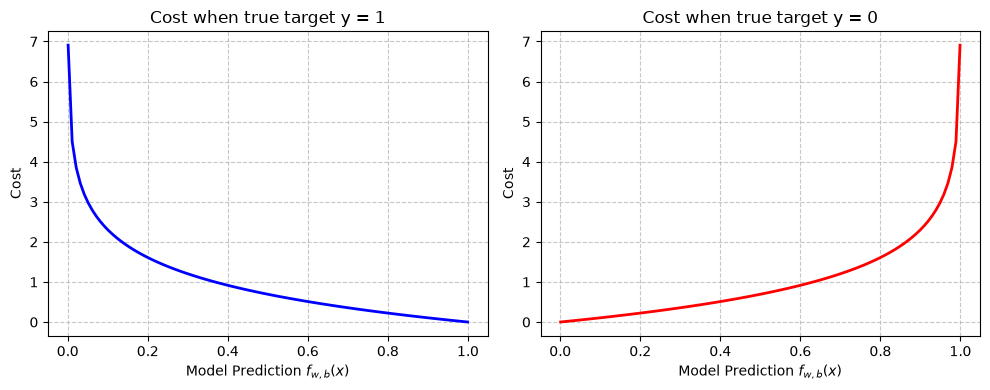

In [9]:
# Visualizing the Piecewise Log Loss Cost Function
f_wb = np.linspace(0.001, 0.999, 100) # Probabilities from just above 0 to just below 1

# Calculate cost for both scenarios
cost_y1 = -np.log(f_wb)       # Cost when true y = 1
cost_y0 = -np.log(1 - f_wb)   # Cost when true y = 0

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# Plot for y = 1
ax[0].plot(f_wb, cost_y1, c="blue", lw=2)
ax[0].set_title("Cost when true target y = 1")
ax[0].set_xlabel("Model Prediction $f_{w,b}(x)$")
ax[0].set_ylabel("Cost")
ax[0].grid(True, linestyle='--', alpha=0.7)

# Plot for y = 0
ax[1].plot(f_wb, cost_y0, c="red", lw=2)
ax[1].set_title("Cost when true target y = 0")
ax[1].set_xlabel("Model Prediction $f_{w,b}(x)$")
ax[1].set_ylabel("Cost")
ax[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

##### **The Unified Equation:**
Because $y$ can only be exactly $0$ or exactly $1$, we can compress this piecewise logic into a single mathematical equation:

$$J(\vec{w},b) = -\frac{1}{m} \sum_{i=1}^{m} \left[ y^{(i)} \log(f_{\vec{w},b}(\vec{x}^{(i)})) + (1 - y^{(i)}) \log(1 - f_{\vec{w},b}(\vec{x}^{(i)})) \right]$$

In [10]:
def compute_cost_logistic(X, y, w, b):
    """
    Computes the log loss cost function for logistic regression.
    """
    m = X.shape[0]
    cost = 0.0
    for i in range(m):
        z_i = np.dot(X[i], w) + b
        f_wb_i = sigmoid(z_i)
        
        # Add a tiny epsilon to prevent log(0) mathematically
        epsilon = 1e-5
        
        loss = -y[i] * np.log(f_wb_i + epsilon) - (1 - y[i]) * np.log(1 - f_wb_i + epsilon)
        cost += loss
        
    return cost / m

### **5. Gradient Descent for Logistic Regression**

We use the exact same algorithm to find the minimum of our new Log Loss bowl:

$$w_j = w_j - \alpha \frac{\partial J(\vec{w},b)}{\partial w_j}$$
$$b = b - \alpha \frac{\partial J(\vec{w},b)}{\partial b}$$

**The Mathematical Magic:**
When you apply calculus to derive the partial derivatives of the complex Log Loss function, the resulting gradient equations look **exactly identical** to the gradients for Linear Regression:

$$\frac{\partial J(\vec{w},b)}{\partial w_j} = \frac{1}{m} \sum_{i=0}^{m-1} (f_{\vec{w},b}(\vec{x}^{(i)}) - y^{(i)})x_j^{(i)}$$

$$\frac{\partial J(\vec{w},b)}{\partial b} = \frac{1}{m} \sum_{i=0}^{m-1} (f_{\vec{w},b}(\vec{x}^{(i)}) - y^{(i)})$$

**The Difference:** The only difference is $f_{\vec{w},b}(\vec{x})$. In linear regression, it is a straight line. In logistic regression, it is the sigmoid curve.

In [11]:
def compute_gradient_logistic(X, y, w, b):
    m, n = X.shape
    dj_dw = np.zeros((n,))
    dj_db = 0.

    for i in range(m):
        f_wb_i = sigmoid(np.dot(X[i], w) + b)
        err_i  = f_wb_i  - y[i]
        for j in range(n):
            dj_dw[j] = dj_dw[j] + err_i * X[i,j]
        dj_db = dj_db + err_i
        
    return dj_dw / m, dj_db / m

def gradient_descent_logistic(X, y, w_in, b_in, alpha, num_iters):
    J_history = []
    w = w_in.copy()
    b = b_in
    
    for i in range(num_iters):
        dj_dw, dj_db = compute_gradient_logistic(X, y, w, b)   
        w = w - alpha * dj_dw               
        b = b - alpha * dj_db               
      
        if i < 100000:
            J_history.append(compute_cost_logistic(X, y, w, b))
            
        if i % (num_iters // 10) == 0:
            print(f"Iteration {i:4d}: Cost {J_history[-1]:8.4f}")
            
    return w, b, J_history

# Train a model on 2D synthetic data
X_train_log = np.array([[0.5, 1.5], [1, 1], [1.5, 0.5], [3, 0.5], [2, 2], [1, 2.5]])
y_train_log = np.array([0, 0, 0, 1, 1, 1])

w_tmp  = np.zeros_like(X_train_log[0])
b_tmp  = 0.
alph = 0.1
iters = 10000

w_out, b_out, _ = gradient_descent_logistic(X_train_log, y_train_log, w_tmp, b_tmp, alph, iters)
print(f"\nOptimized weights: {w_out}, bias: {b_out:.4f}")

Iteration    0: Cost   0.6846
Iteration 1000: Cost   0.1591
Iteration 2000: Cost   0.0846
Iteration 3000: Cost   0.0570
Iteration 4000: Cost   0.0429
Iteration 5000: Cost   0.0343
Iteration 6000: Cost   0.0286
Iteration 7000: Cost   0.0245
Iteration 8000: Cost   0.0214
Iteration 9000: Cost   0.0190

Optimized weights: [5.28123029 5.07815608], bias: -14.2224


### **6. Making Predictions and Decision Boundaries**

Once we have learned the optimal weights and bias, we can calculate the probability for new inputs and apply a $0.5$ threshold to classify them.

In [12]:
def predict_logistic(X, w, b):
    m = X.shape[0]
    p = np.zeros(m)
    for i in range(m):
        f_wb_i = sigmoid(np.dot(X[i], w) + b)
        p[i] = 1 if f_wb_i >= 0.5 else 0
    return p

predictions = predict_logistic(X_train_log, w_out, b_out)
accuracy = np.mean(predictions == y_train_log) * 100

print(f"Model Predictions: {predictions}")
print(f"Actual Targets:    {y_train_log}")
print(f"Training Accuracy: {accuracy}%")

Model Predictions: [0. 0. 0. 1. 1. 1.]
Actual Targets:    [0 0 0 1 1 1]
Training Accuracy: 100.0%


### **Visualizing the Decision Boundary**

To truly understand what the model just learned, we plot our 2D dataset and draw the line where the model switches from predicting $0$ to predicting $1$.

Mathematically, this happens where $w_1x_1 + w_2x_2 + b = 0$. 
Solving for $x_2$, we get the line equation: $x_2 = \frac{-w_1x_1 - b}{w_2}$

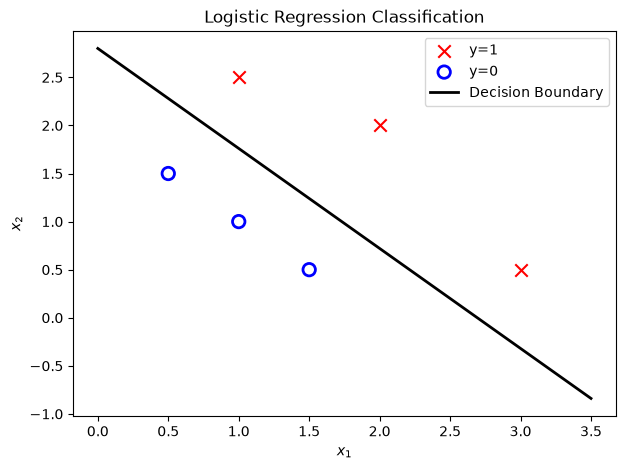

In [13]:
fig, ax = plt.subplots(figsize=(7, 5))

pos = y_train_log == 1
neg = y_train_log == 0

ax.scatter(X_train_log[pos, 0], X_train_log[pos, 1], marker='x', s=80, c='red', label="y=1")
ax.scatter(X_train_log[neg, 0], X_train_log[neg, 1], marker='o', s=80, facecolors='none', edgecolors='blue', lw=2, label="y=0")

# Calculate boundary points using algebraic formula
x1_points = np.array([0, 3.5])
x2_points = (-w_out[0] * x1_points - b_out) / w_out[1]

ax.plot(x1_points, x2_points, c="black", lw=2, label="Decision Boundary")
ax.set_title("Logistic Regression Classification")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.legend()
plt.show()

---
### **7. Overfitting and Generalization**

By engineering polynomial features ($x_1^2, x_2^3$), we can create non-linear boundaries (circles, wavy lines). This introduces a risk:

1.  **Underfitting (High Bias):** Model is too simple (e.g., straight line on circular data).
2.  **Overfitting (High Variance):** Model draws a convoluted curve that hits every single noise point, failing to generalize.
3.  **Just Right:** The model captures the true overarching pattern.

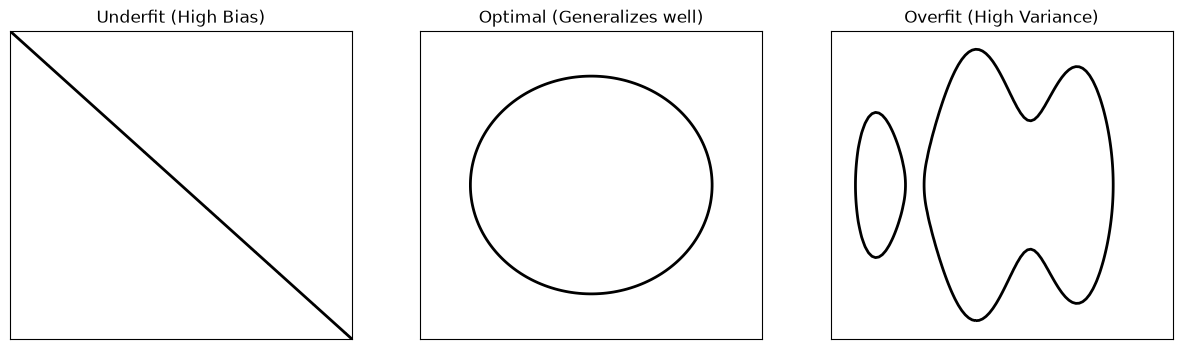

In [14]:
# Visualizing Underfit, Optimal, and Overfit boundaries conceptually
xx, yy = np.meshgrid(np.linspace(-1, 1, 100), np.linspace(-1, 1, 100))

# Dummy mathematical functions to generate boundary shapes
Z_under = xx + yy                             # A straight line
Z_opt = xx**2 + yy**2 - 0.5                   # A smooth circle
Z_over = xx**2 + yy**2 + 0.3*np.sin(10*xx) - 0.5 # A wavy, over-complex circle

fig, ax = plt.subplots(1, 3, figsize=(15, 4))

ax[0].contour(xx, yy, Z_under, levels=[0], colors='k', linewidths=2)
ax[0].set_title("Underfit (High Bias)")

ax[1].contour(xx, yy, Z_opt, levels=[0], colors='k', linewidths=2)
ax[1].set_title("Optimal (Generalizes well)")

ax[2].contour(xx, yy, Z_over, levels=[0], colors='k', linewidths=2)
ax[2].set_title("Overfit (High Variance)")

for a in ax:
    a.set_xticks([])
    a.set_yticks([])
    a.grid(False)
    
plt.show()

### **8. Regularization (L2)**

To solve overfitting, we add a **Regularization Penalty** to the end of our Cost Function, controlled by $\lambda$ (lambda). This forces the algorithm to make the weights ($w_j$) extremely small, naturally smoothing out the curve.

##### **The Regularized Cost Function:**
$$J(\vec{w},b) = \text{Original Cost} + \frac{\lambda}{2m} \sum_{j=1}^{n} w_j^2$$

*(By convention, we do NOT penalize the bias $b$.)*

##### **The Regularized Gradient Update:**
We add a penalty term strictly to the $w_j$ update:

$$\frac{\partial J(\vec{w},b)}{\partial w_j} = \text{Original Gradient} + \frac{\lambda}{m} w_j$$
$$\frac{\partial J(\vec{w},b)}{\partial b} = \text{Original Gradient} \quad (\text{No change})$$

In [15]:
def compute_cost_logistic_reg(X, y, w, b, lambda_=1):
    m, n = X.shape
    cost_without_reg = compute_cost_logistic(X, y, w, b)
    
    reg_cost = 0.
    for j in range(n):
        reg_cost += (w[j]**2)
    reg_cost = (lambda_ / (2 * m)) * reg_cost
    
    return cost_without_reg + reg_cost

def compute_gradient_logistic_reg(X, y, w, b, lambda_=1):
    m, n = X.shape
    dj_dw, dj_db = compute_gradient_logistic(X, y, w, b)
    
    # Add penalty to w gradients
    for j in range(n):
        dj_dw[j] = dj_dw[j] + (lambda_ / m) * w[j]
        
    return dj_dw, dj_db

dj_dw_reg, dj_db_reg = compute_gradient_logistic_reg(X_train_log, y_train_log, w_out, b_out, lambda_=10)
print(f"Regularized Gradients - dj_dw: {dj_dw_reg}, dj_db: {dj_db_reg:.4f}")

Regularized Gradients - dj_dw: [8.80071415 8.46225432], dj_db: 0.0037
